# Arccos Targeted Diagnostics

Deep-dives on the four highest-stroke-ROI questions surfaced by the broader
Arccos Course Analysis notebook:

1. **125-150 yd approach deep-dive** — the single biggest specific SG leak
   in your game (−0.42 SG/shot × 175+ shots). This section slices by club,
   lie, and wind to find the actual pattern.
2. **Putt make-% by distance** — splits putting (−3.1 SG/round overall) by
   distance band and benchmarks against the PGA Tour. Reveals whether the
   leak is short putts (Aim Point / line) or lag putts (speed control).
3. **Lie-penalty matrix** — what missing the fairway costs per club. Drives
   driver-vs-3W decisions on tight holes with numbers, not vibes.
4. **Twin Oaks hole-by-hole** — your home course (≥30 rounds). Identifies
   nemesis holes that need pre-round mental prep + scoring-opportunity holes
   that you should be more aggressive on.

In [1]:
# --- Setup ---------------------------------------------------------
# Walk up to find the repo root (contains the `arccos` package) and put
# it on sys.path so this notebook runs from anywhere.
import sys
from pathlib import Path
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / "arccos").is_dir():
    _p = _p.parent
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arccos import load_arccos
from arccos import diagnostics as dx

plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3})

data = load_arccos()
print(data.summary())

Arccos store: C:\Users\zfreitas\golf-data
  rounds:        58  date range 2023-07-28 to 2026-09-10
  holes:        670
  shots:       3386  GPS=yes
  clubs.csv:     39  (paired + unpaired, mixed)
  paired bag:    14  (authoritative — from clubs_v6.json)
  handicaps:     50  (per-round shot-type hcp series)
  courses:        9  (slope/rating from courses/*.json)
  round_dash:    58  (per-round SG splits, pace, hole scores)


## 1. The 125-150 yd approach deep-dive

Slice every approach shot starting in the 125-150 yd band and break it down
by club, lie, and wind. Goal: turn "approach is leaking" into a specific
diagnosis you can attack on the range.

In [2]:
res = dx.approach_band_deepdive(data, lo=125, hi=150)
print(f"Total shots in 125-150 yd band: {res['n_total']}")
print(f"Total SG lost in this band: {res['total_sg_lost']:.1f} strokes "
      f"({res['total_sg_lost']/res['n_total']:.2f} per shot avg)")

Total shots in 125-150 yd band: 193
Total SG lost in this band: -87.2 strokes (-0.45 per shot avg)


In [3]:
print("--- By CLUB ---")
res["by_club"]

--- By CLUB ---


,shots,avg_sg,median_proximity_ft
display_club,,,
6 Iron,69,-0.41,63.00
Hybrid,42,-0.52,92.55
7 Iron,35,-0.43,74.70
5 Iron,31,-0.49,90.90
8 Iron,10,-0.35,124.35
Pitching Wedge,2,-0.57,196.35
9 Iron,2,-0.39,93.75
3 Hybrid,1,-0.63,123.60
3 Wood,1,-0.44,131.70


In [4]:
print("--- By LIE ---")
res["by_lie"]

--- By LIE ---


,shots,avg_sg
lie_approx,,
rough,82,-0.30
tee,63,-0.56
fairway,48,-0.57


In [5]:
print("--- By WIND ---")
res["by_wind"]

--- By WIND ---


,shots,avg_sg
wind_bucket,,
calm <5,18,-0.41
5-10,171,-0.46
10-15,4,-0.36


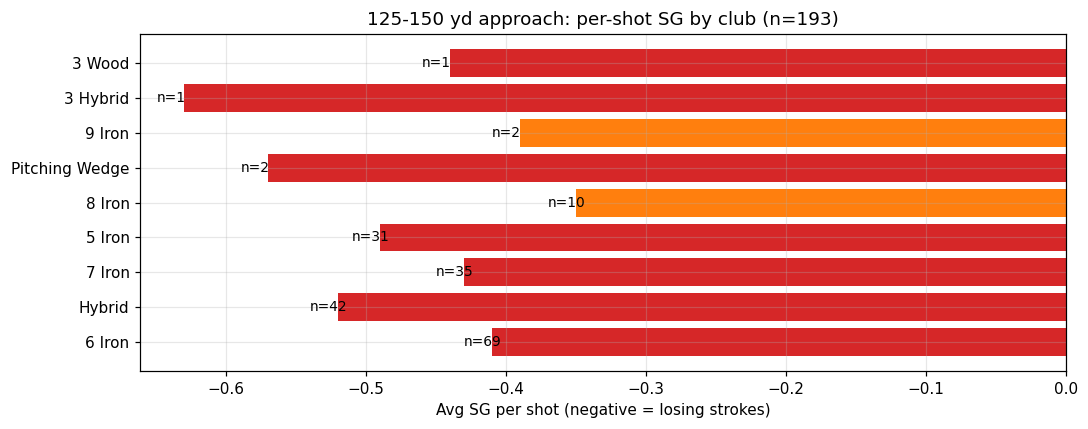

In [6]:
# Visualize the by-club breakdown.
fig, ax = plt.subplots(figsize=(10, 4))
bc = res["by_club"]
colors = ["#d62728" if v < -0.4 else "#ff7f0e" if v < -0.2 else "#2ca02c"
          for v in bc["avg_sg"]]
ax.barh(bc.index.astype(str), bc["avg_sg"], color=colors)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title(f"125-150 yd approach: per-shot SG by club (n={res['n_total']})")
ax.set_xlabel("Avg SG per shot (negative = losing strokes)")
for i, (n, v) in enumerate(zip(bc["shots"], bc["avg_sg"])):
    ax.text(v - 0.02 if v < 0 else v + 0.02, i, f"n={n}",
            va="center", fontsize=9)
plt.tight_layout(); plt.show()

**How to read it.** The shot count next to each bar matters as much as the
SG figure — a brutally negative SG with n=3 might be noise; the same number
with n=50 is a real signal. Cross-reference against the by-lie and by-wind
tables to figure out whether it's the club, the situation, or the user.

## 2. Putt make-% by distance

First-putt-only (phantom 0-distance putts filtered out — Arccos logs those
when the ball is already at the hole). Buckets are inclusive of the lower
bound, exclusive of the upper. Tour benchmark from Broadie's published
PGA averages.

In [7]:
putts = dx.putt_make_by_distance(data)
putts

,band,attempts,makes,make_pct,tour_pct,gap_vs_tour
0,0-3 ft,2,1,50.0,99,-49.0
1,3-5 ft,26,14,53.8,88,-34.2
2,5-8 ft,51,12,23.5,58,-34.5
3,8-12 ft,66,13,19.7,33,-13.3
4,12-18 ft,100,19,19.0,17,2.0
5,18-25 ft,127,20,15.7,8,7.7
6,25-35 ft,130,19,14.6,4,10.6
7,35+ ft,159,16,10.1,2,8.1


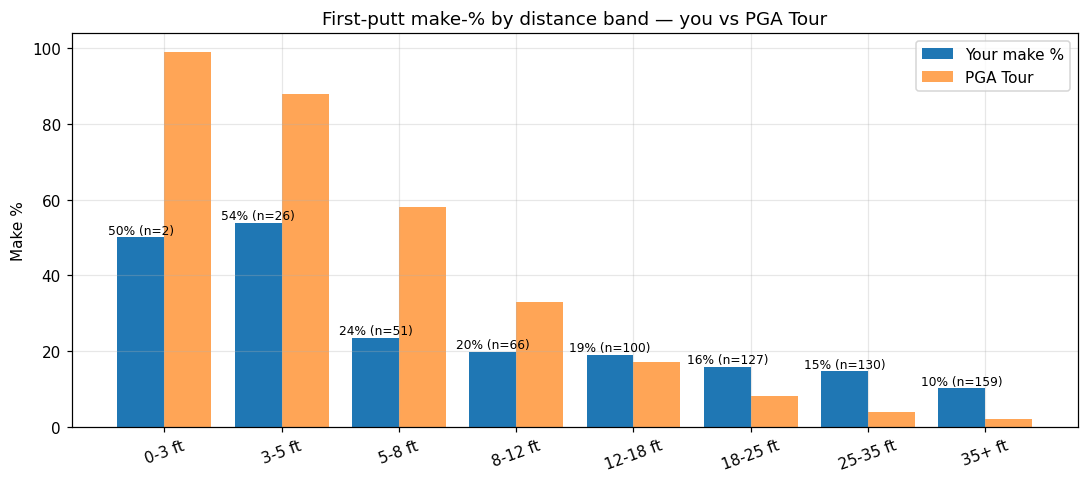

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(putts))
width = 0.4
ax.bar(x - width/2, putts["make_pct"], width, label="Your make %",
       color="#1f77b4")
ax.bar(x + width/2, putts["tour_pct"], width, label="PGA Tour",
       color="#ff7f0e", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(putts["band"], rotation=20)
ax.set_ylabel("Make %")
ax.set_title("First-putt make-% by distance band — you vs PGA Tour")
ax.legend()
for i, (m, n) in enumerate(zip(putts["make_pct"], putts["attempts"])):
    ax.text(i - width/2, m + 1, f"{m:.0f}% (n={n})", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation guide.** Where you're *below* Tour, that's a real practice
opportunity. Where you're *at or above* Tour (often the 18+ ft bands), don't
overinvest — Tour numbers in those bands are surprisingly low because making
a 25-ft putt is mostly luck even for the best players. Long-putt practice
is about avoiding 3-putts (lag distance control), not making them.

## 3. Lie-penalty matrix

Smart Distance per club split by lie (tee / fairway / rough / sand) from
`clubs.csv`. **Rough penalty** = fairway distance − rough distance, i.e.
how much carry you lose by missing the fairway. Negative penalty means
you actually got *more* distance from the rough (small samples or hot
rolls — interpret with caution).

In [9]:
lies = dx.lie_penalty_matrix(data)
lies

,display_club,From tee (yd),From fairway (yd),From rough (yd),From sand (yd),n shots,Rough penalty (yd)
1,3 Wood,223.1,192.9,208.0,201.5,30,-15.0
0,Driver,219.0,NaN,NaN,NaN,97,NaN
8,3 Hybrid,180.8,181.2,171.8,NaN,37,9.0
9,Hybrid,169.3,161.0,158.1,NaN,21,3.0
15,5 Iron,155.3,141.7,150.7,NaN,23,-9.0
19,6 Iron,142.5,141.4,138.1,NaN,23,3.0
23,7 Iron,132.9,126.0,137.7,NaN,19,-12.0
24,8 Iron,124.9,123.4,121.9,NaN,20,2.0
30,Pitching Wedge,120.4,99.3,99.4,NaN,12,-0.0
27,9 Iron,113.8,106.8,107.3,91.9,12,-0.0


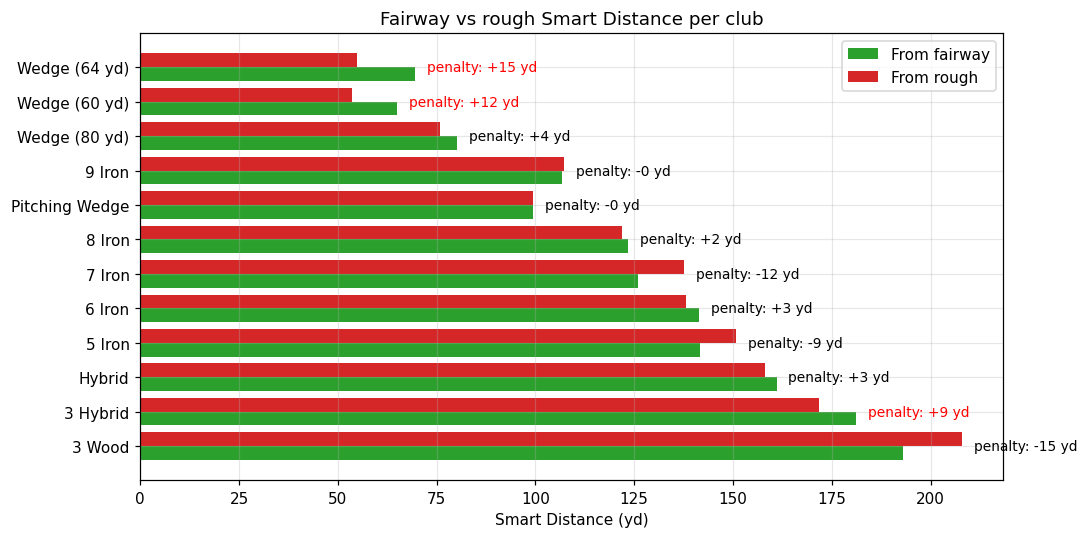

In [10]:
# Visualize fairway vs rough for clubs with enough data.
visible = lies[lies["n shots"] >= 8].dropna(subset=["From fairway (yd)", "From rough (yd)"])
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(visible))
ax.barh(y - 0.2, visible["From fairway (yd)"], 0.4, label="From fairway",
        color="#2ca02c")
ax.barh(y + 0.2, visible["From rough (yd)"], 0.4, label="From rough",
        color="#d62728")
ax.set_yticks(y)
ax.set_yticklabels(visible["display_club"])
ax.set_xlabel("Smart Distance (yd)")
ax.set_title("Fairway vs rough Smart Distance per club")
ax.legend()
for i, (f, r) in enumerate(zip(visible["From fairway (yd)"], visible["From rough (yd)"])):
    pen = f - r
    color = "red" if pen > 5 else "black"
    ax.text(max(f, r) + 3, i, f"penalty: {pen:+.0f} yd",
            va="center", fontsize=9, color=color)
plt.tight_layout(); plt.show()

**Decision implication.** When a club's rough penalty is 10+ yards, missing
the fairway with that club is genuinely costly. On tight par-4s where you
can reach the green with a 3-wood from the fairway (penalty 0 yd) vs a
driver from the rough (penalty 10-20 yd), the conservative tee shot may
actually be the longer one to the green.

## 4. Twin Oaks hole-by-hole

Per-hole performance at Twin Oaks GC (your most-played course). Three
ranks help distinguish different kinds of "bad hole":

- **`avg_rank`** — sorted by mean strokes-over-par. Highlights holes where
  blow-ups (triples, others) inflate the average.
- **`double_rank`** — sorted by % of rounds you make double-bogey-or-worse.
  Highlights holes where the *typical* outcome is bad, not just the worst
  outcome. This often matches "feel" better than the average.
- **`nemesis_rank`** — composite of the two. Lower = worse hole overall.

A hole with `avg_rank=1` but `double_rank=10` blows up occasionally but
plays normally most rounds. A hole with `double_rank=1` but `avg_rank=5`
beats you down day after day even if it rarely cataclysmically explodes.

In [11]:
twin = dx.twin_oaks_hole_heatmap(data)
twin

,rounds,par,avg_to_par,median_to_par,bogey_or_worse_pct,double_or_worse_pct,par_or_better_pct,worst_to_par,best_to_par,avg_rank,double_rank,nemesis_rank
hole_id,,,,,,,,,,,,
1,39,4,1.5,1.0,87.2,48.7,12.8,4,0,3,5,5
2,40,5,1.4,1.5,75.0,50.0,25.0,5,-4,4,2,2
3,40,3,1.4,1.0,77.5,47.5,22.5,3,0,4,6,7
4,40,4,1.4,1.5,72.5,50.0,27.5,4,-1,4,2,2
5,39,5,1.0,1.0,66.7,28.2,33.3,4,-1,13,13,13
6,39,4,1.3,1.0,79.5,43.6,20.5,4,-1,10,8,10
7,39,3,1.2,1.0,69.2,38.5,30.8,3,0,12,10,11
8,38,4,1.4,1.5,73.7,50.0,26.3,3,0,4,2,2
9,38,4,1.6,1.0,84.2,47.4,15.8,4,-1,1,7,5


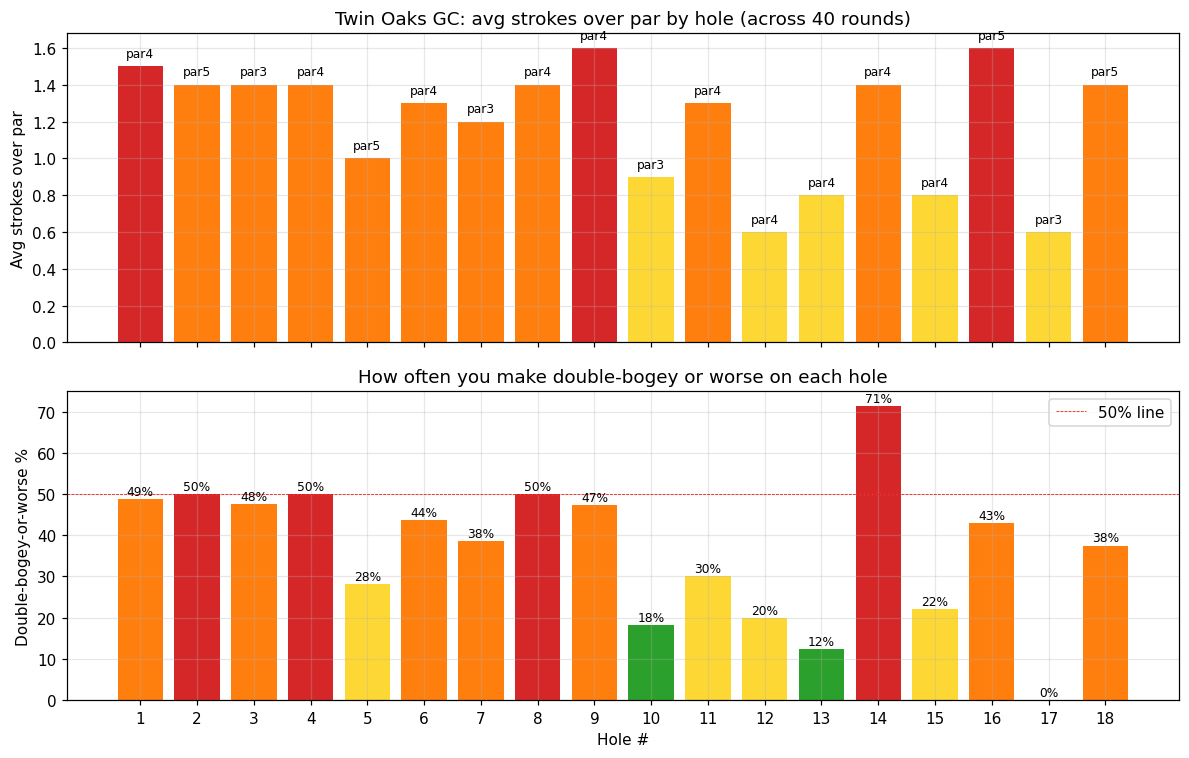

In [12]:
# Two-panel view: avg-to-par on top, double-bogey-or-worse % below.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Panel 1: average strokes over par
colors1 = ["#d62728" if v >= 1.5 else "#ff7f0e" if v >= 1.0
           else "#fdd835" if v >= 0.5 else "#2ca02c" for v in twin["avg_to_par"]]
ax1.bar(twin.index.astype(str), twin["avg_to_par"], color=colors1)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_title(f"Twin Oaks GC: avg strokes over par by hole "
              f"(across {twin['rounds'].max()} rounds)")
ax1.set_ylabel("Avg strokes over par")
for i, (par, n, v) in enumerate(zip(twin["par"], twin["rounds"], twin["avg_to_par"])):
    ax1.text(i, v + 0.05, f"par{par}", ha="center", fontsize=8)

# Panel 2: double-bogey-or-worse frequency — "feels-like-a-nemesis" metric
colors2 = ["#d62728" if v >= 50 else "#ff7f0e" if v >= 35
           else "#fdd835" if v >= 20 else "#2ca02c" for v in twin["double_or_worse_pct"]]
ax2.bar(twin.index.astype(str), twin["double_or_worse_pct"], color=colors2)
ax2.axhline(50, color="red", linewidth=0.5, linestyle="--", label="50% line")
ax2.set_title("How often you make double-bogey or worse on each hole")
ax2.set_xlabel("Hole #")
ax2.set_ylabel("Double-bogey-or-worse %")
ax2.legend(loc="upper right")
for i, v in enumerate(twin["double_or_worse_pct"]):
    ax2.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=8)

plt.tight_layout(); plt.show()

**Action plan.** Holes high on the **double-bogey-frequency** chart are
where pre-round visualization + a conservative game plan pay off most —
those are the holes that beat you up consistently. Holes high on the
**average** chart but moderate on double-bogey-frequency are blow-up holes
— a more aggressive plan with disciplined bail-out is the lever there.

Cross-reference with §1: if hole 3 is a double-bogey trap and you're hitting
mostly 7-iron/8-iron from the tee, the 125-150 yd approach SG leak is the
upstream cause. Fix the strike, fix the hole.

## 5. Range (GC3) vs course (Arccos) — 7-iron comparison

Side-by-side distributions of your 7-iron from the launch monitor and from
real on-course shots. **Currently 7-iron only** because that's all the GC3
data we have. Adding sessions for other clubs is the path to expanding
this section.

**Unit caveat (important).** GC3 'Carry' is launch-monitor carry, no roll.
Arccos 'shot_distance_yd' is on-course total — carry + bounce + roll.
GC3's 'Total' uses a modeled roll that's *very* aggressive for irons (60+
yards on a 7-iron implies a hardpan bounce, not realistic green-holding).
Best comparison: **GC3 carry vs Arccos total minus ~7 yd of typical iron
roll** — the gap that remains is the on-course performance penalty (real
lies, wind, pressure swings, partial swings to specific yardages).

In [13]:
res = dx.range_vs_course_7i(data)

# Stats table
stats_rows = []
for key in ("gc3_carry_stats", "gc3_total_stats", "arc_total_stats", "gc3_offline_stats"):
    s = res[key]
    if s["n"] == 0: continue
    stats_rows.append(s)
stats_df = pd.DataFrame(stats_rows).set_index("label")
stats_df

,n,mean,std,p20,median,p80,min,max
label,,,,,,,,
"GC3 carry (yd, range, no roll)",188,118.1,31.4,92.2,124.2,143.2,7.0,193.7
"GC3 total (yd, range, modeled roll)",188,170.8,30.0,148.2,175.5,195.6,62.2,253.9
"Arccos total (yd, course)",84,88.9,46.4,27.5,110.4,127.4,7.8,159.2
"GC3 offline (yd, +R/-L)",188,-9.1,14.9,-22.1,-10.2,3.3,-37.9,40.8


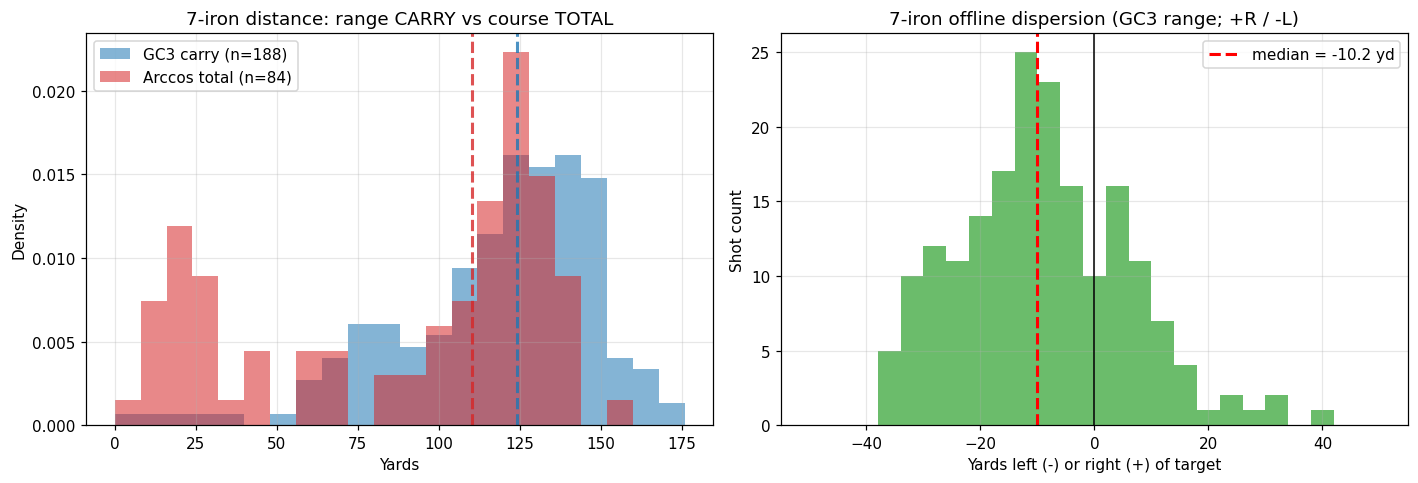

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: distance comparison (GC3 carry vs Arccos total)
bins = range(0, 180, 8)
axes[0].hist(res["gc3_carry"], bins=bins, alpha=0.55, color="#1f77b4",
             label=f"GC3 carry (n={len(res['gc3_carry'])})", density=True)
axes[0].hist(res["arc_total"], bins=bins, alpha=0.55, color="#d62728",
             label=f"Arccos total (n={len(res['arc_total'])})", density=True)
axes[0].axvline(res["gc3_carry"].median(), color="#1f77b4",
                linestyle="--", linewidth=2, alpha=0.8)
axes[0].axvline(res["arc_total"].median(), color="#d62728",
                linestyle="--", linewidth=2, alpha=0.8)
axes[0].set_title("7-iron distance: range CARRY vs course TOTAL")
axes[0].set_xlabel("Yards"); axes[0].set_ylabel("Density")
axes[0].legend()

# Panel 2: GC3 offline dispersion (range only — course can't measure this)
axes[1].hist(res["gc3_offline"], bins=range(-50, 51, 4), color="#2ca02c", alpha=0.7)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axvline(res["gc3_offline"].median(), color="red", linestyle="--",
                linewidth=2, label=f"median = {res['gc3_offline'].median():.1f} yd")
axes[1].set_title("7-iron offline dispersion (GC3 range; +R / -L)")
axes[1].set_xlabel("Yards left (-) or right (+) of target")
axes[1].set_ylabel("Shot count")
axes[1].legend()

plt.tight_layout(); plt.show()

**How to read it.**

*Distance panel (left)*: the range carry (blue) being **right of** course
total (red) is the gap to close. Range carry of 122 yd median should be
roughly equivalent to course total of ~129 (carry + 7 roll). If course
total is well below that, you're losing distance on course beyond what
roll accounts for — pressure, partial swings, less-than-ideal lies.

*Offline panel (right)*: course Arccos can't easily measure "offline"
without knowing what you aimed at (the pin isn't always the target). The
GC3 offline distribution is the cleanest lateral-dispersion signal we
have. A median significantly left or right of 0 indicates a swing-path
bias — that's a range diagnostic that translates directly to on-course
misses on dogleg holes.

**Caveat.** GC3 sessions only have 7-iron right now. Adding more clubs
to the GC3 captures (driver, wedges) would let this section expand to a
true per-club range-vs-course comparison.